# Tech Challenge Fase 1 — Análise de Dados Olist

Análise exploratória dos pedidos, logística, avaliações dos clientes e relação entre preço e satisfação.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

## 1. Importação das bases

Nesta etapa são carregados os datasets utilizados na análise.

In [25]:
orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

## 2. Preparação dos dados — Datas

Conversão das colunas de data para o formato `datetime`, permitindo realizar cálculos relacionados ao prazo de entrega.

In [5]:
date_columns = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

## 3. Preparação dos dados — Categorias

Integração da tabela de tradução para facilitar a interpretação das categorias de produtos.

In [6]:
products = products.merge(translation, on='product_category_name', how='left')

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


## 4. Consolidação das bases

Criação de uma tabela única (`df`) a partir do relacionamento entre pedidos, itens, produtos, clientes e avaliações.

In [7]:
df = (orders
    .merge(reviews, on='order_id', how='left')
    .merge(order_items, on='order_id', how='left')
    .merge(products[['product_id',
                     'product_category_name_english']],
           on='product_id',
           how='left')
)

## 5. Criação das métricas

Nesta etapa são criadas as principais métricas utilizadas para avaliar desempenho logístico e financeiro.

### 5.1 Tempo de entrega dos pedidos

Calcula o tempo, em dias, entre a compra e a entrega ao cliente.

In [8]:
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

### 5.2 Atraso nos pedidos

Identifica se o pedido foi entregue após a data estimada.

In [9]:
df['late_delivery'] = np.where(df['order_delivered_customer_date'] > df['order_estimated_delivery_date'], 1, 0)

### 5.3 Valor total dos pedidos

Calcula o valor total considerando preço do produto e frete.

In [10]:
df['total_order_value'] = (df['price'] + df['freight_value'])

### 5.4 Percentual de frete

Calcula a participação do frete em relação ao preço do produto.

In [11]:
df['freight_percent'] = (df['freight_value'] / df['price']) * 100

### 5.5 Remoção de pedidos não entregues

Para as análises de logística e satisfação, são considerados somente os pedidos que possuem data de entrega.

In [12]:
df = df[df['delivery_time'].notna()]

## 6. Análise das avaliações dos clientes

Distribuição das notas atribuídas pelos clientes aos pedidos.

In [13]:
review_distribution = (df['review_score'].value_counts().sort_index())

print(review_distribution)

review_score
1.0    12578
2.0     3700
3.0     9243
4.0    21184
5.0    63307
Name: count, dtype: int64


### 6.1 Distribuição das avaliações

Visualização da quantidade de avaliações para cada nota.

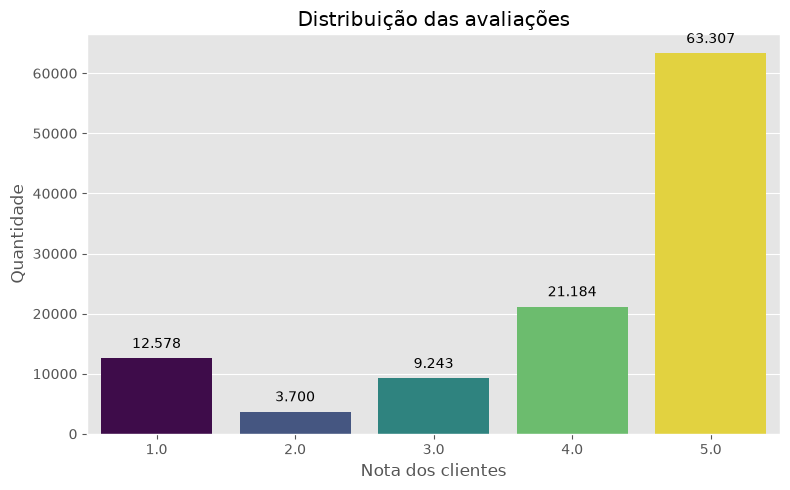

In [27]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='review_score',
    hue='review_score',
    palette='viridis',
    legend=False
)

plt.title('Distribuição das avaliações')
plt.xlabel('Nota dos clientes')
plt.ylabel('Quantidade')

for barra in ax.patches:
    valor = int(barra.get_height())
    
    ax.annotate(
        f'{valor:,}'.replace(',', '.'),
        (barra.get_x() + barra.get_width() / 2, valor),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

In [15]:
print(df['review_score'].mean())

4.081172962949497


In [16]:
delay_analysis = (df.groupby('late_delivery')['review_score'].mean().reset_index())

print(delay_analysis)

   late_delivery  review_score
0              0      4.210476
1              1      2.548884


C:\Users\gabri\AppData\Local\Temp\ipykernel_27568\1414831202.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delay_analysis, x='late_delivery', y='review_score', palette='viridis')


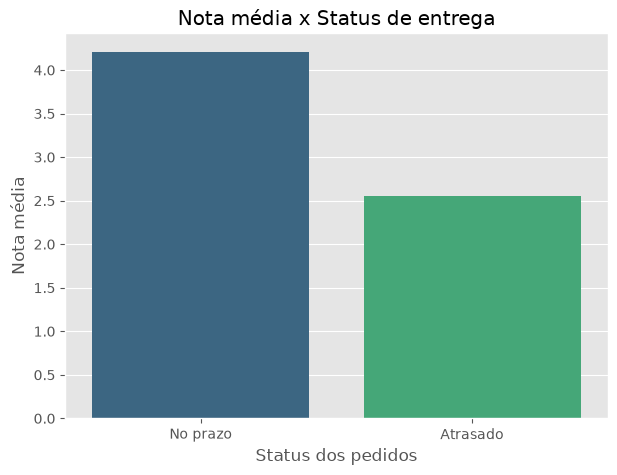

In [17]:
plt.figure(figsize=(7,5))

sns.barplot(data=delay_analysis, x='late_delivery', y='review_score', palette='viridis')

plt.xticks([0,1], ['No prazo', 'Atrasado'])

plt.ylabel('Nota média')
plt.title('Nota média x Status de entrega')
plt.xlabel('Status dos pedidos')

plt.show()

### Insight — Impacto do atraso na satisfação

A logística apresenta impacto relevante na satisfação do cliente. Pedidos entregues no prazo receberam, em média, 4,2 estrelas, enquanto entregas atrasadas tiveram média de 2,6 estrelas. O resultado indica que cumprir o prazo prometido é um fator importante para melhorar a experiência do cliente.

In [18]:
delivery_review = (df.groupby('review_score')['delivery_time'].mean().reset_index())

print(delivery_review)

   review_score  delivery_time
0           1.0      19.116632
1           2.0      15.337838
2           3.0      13.581197
3           4.0      11.752644
4           5.0      10.191464


### 6.2 Tempo de entrega x Nota dos clientes

Comparação entre o tempo médio de entrega e a avaliação atribuída pelos clientes.

C:\Users\gabri\AppData\Local\Temp\ipykernel_27568\2509619768.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delivery_review, x='review_score', y='delivery_time', palette='viridis')


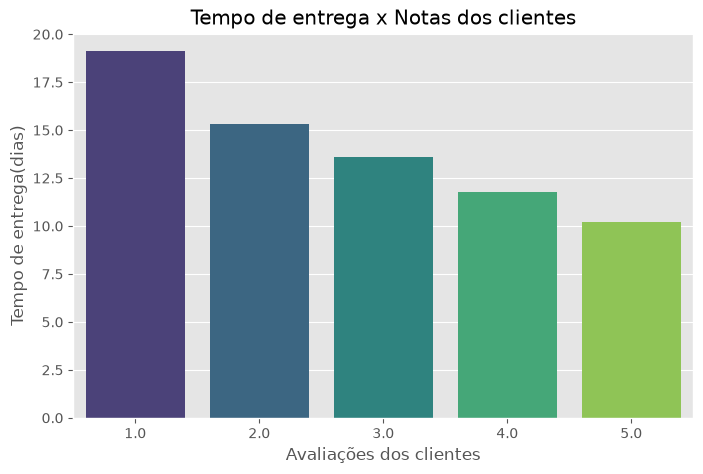

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(data=delivery_review, x='review_score', y='delivery_time', palette='viridis')

plt.title('Tempo de entrega x Notas dos clientes')
plt.ylabel('Tempo de entrega(dias)')
plt.xlabel('Avaliações dos clientes')
plt.show()

### Insight — Tempo de entrega e satisfação

O gráfico apresenta uma relação decrescente: à medida que o tempo de entrega aumenta, a avaliação média tende a diminuir. Isso reforça a importância da eficiência logística para a experiência do cliente.

## 7. Relação entre preço e satisfação

Análise da associação entre o preço dos produtos e as avaliações dos clientes.

In [20]:
price_review = (df.groupby('review_score')['price'].mean().reset_index())

print(price_review)

   review_score       price
0           1.0  123.346362
1           2.0  114.193716
2           3.0  109.801587
3           4.0  118.409193
4           5.0  121.163306


### 7.1 Preço médio x Nota dos clientes

Comparação entre o preço médio dos produtos e a nota atribuída pelos clientes.

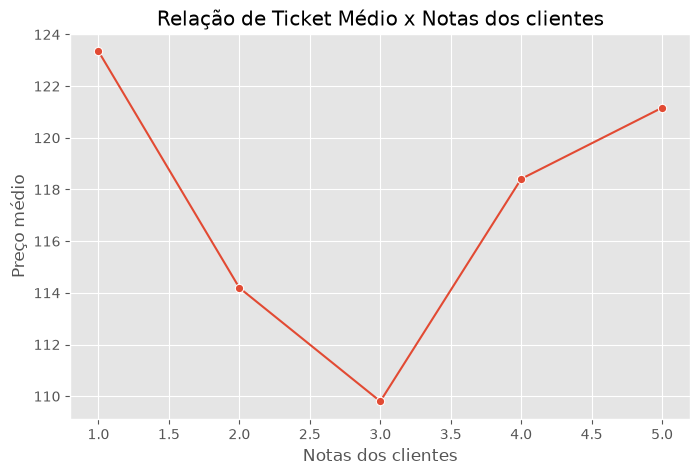

In [21]:
plt.figure(figsize=(8,5))

sns.lineplot(data=price_review, x='review_score', y='price', marker='o')

plt.title('Relação de Ticket Médio x Notas dos clientes')
plt.ylabel('Preço médio')
plt.xlabel('Notas dos clientes')
plt.show()

### Insight — Preço e avaliações

Produtos de maior valor apresentam avaliações mais extremas: quando atendem às expectativas, tendem a receber notas altas; quando decepcionam, tendem a receber notas baixas. Produtos de menor valor concentram avaliações mais intermediárias.

## 8. Resumo dos KPIs

Consolidação dos principais indicadores encontrados na análise.

In [22]:
print('Nota média:', round(df['review_score'].mean(),2))
print('Tempo médio:', round(df['delivery_time'].mean(),2))
print('Preço médio:', round(df['price'].mean(),2))
print('Frete médio:', round(df['freight_value'].mean(),2))
print('Pedidos analisados:', len(df))

Nota média: 4.08
Tempo médio: 12.01
Preço médio: 119.81
Frete médio: 19.94
Pedidos analisados: 110839
